Project Title

Heart Disease Prediction Using Machine Learning Classification Algorithms

PROBLEM STATEMENT

Heart disease is one of the leading causes of death worldwide. Early identification of individuals who are at high risk of developing heart disease can help healthcare professionals provide timely treatment and preventive care. However, manually analyzing multiple health factors such as age, blood pressure, cholesterol, smoking habits, diabetes, and body mass index is time-consuming and may lead to inaccurate decisions.

The objective of this project is to develop a machine learning classification model that predicts whether a person is likely to develop coronary heart disease within the next 10 years using the Framingham Heart Disease dataset. The project compares the performance of multiple classification algorithms, including Logistic Regression, Decision Tree, Random Forest, K-Nearest Neighbors (KNN), Support Vector Machine (SVM), and Naive Bayes, to identify the most accurate model for heart disease prediction.

OBJECTIVES

To preprocess and clean the Framingham Heart Disease dataset.
To perform Exploratory Data Analysis (EDA) for understanding the data.
To build multiple machine learning classification models.
To evaluate each model using Accuracy, Precision, Recall, F1-Score, Confusion Matrix, and ROC Curve.
To compare the performance of all models and select the best model for predicting heart disease risk.

EDA (Exploratory Data Analysis)

 Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

LOAD THE DATASET

In [ ]:
df = pd.read_csv(r"C:\Users\bkdbh\Downloads\framingham.csv")
df.head()

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


Display Dataset

In [ ]:
df.tail()

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
4233,1,50,1.0,1,1.0,0.0,0,1,0,313.0,179.0,92.0,25.97,66.0,86.0,1
4234,1,51,3.0,1,43.0,0.0,0,0,0,207.0,126.5,80.0,19.71,65.0,68.0,0
4235,0,48,2.0,1,20.0,NaN,0,0,0,248.0,131.0,72.0,22.00,84.0,86.0,0
4236,0,44,1.0,1,15.0,0.0,0,0,0,210.0,126.5,87.0,19.16,86.0,NaN,0
4237,0,52,2.0,0,0.0,0.0,0,0,0,269.0,133.5,83.0,21.47,80.0,107.0,0


In [ ]:
df.sample(5)

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
2049,0,52,1.0,0,0.0,0.0,0,0,0,275.0,112.0,71.0,25.68,80.0,NaN,0
318,1,44,3.0,1,15.0,0.0,0,0,0,340.0,125.0,78.0,26.41,56.0,90.0,0
153,0,66,1.0,0,0.0,0.0,0,1,0,214.0,212.0,104.0,25.32,57.0,84.0,1
2328,1,66,4.0,1,20.0,0.0,0,1,0,273.0,145.0,88.0,25.41,69.0,74.0,1
2396,0,46,3.0,0,0.0,0.0,0,0,0,193.0,110.0,68.0,22.19,68.0,65.0,0


Dataset Information

In [ ]:
df.shape

(4238, 16)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4238 entries, 0 to 4237
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   male             4238 non-null   int64  
 1   age              4238 non-null   int64  
 2   education        4133 non-null   float64
 3   currentSmoker    4238 non-null   int64  
 4   cigsPerDay       4209 non-null   float64
 5   BPMeds           4185 non-null   float64
 6   prevalentStroke  4238 non-null   int64  
 7   prevalentHyp     4238 non-null   int64  
 8   diabetes         4238 non-null   int64  
 9   totChol          4188 non-null   float64
 10  sysBP            4238 non-null   float64
 11  diaBP            4238 non-null   float64
 12  BMI              4219 non-null   float64
 13  heartRate        4237 non-null   float64
 14  glucose          3850 non-null   float64
 15  TenYearCHD       4238 non-null   int64  
dtypes: float64(9), int64(7)
memory usage: 529.9 KB


In [ ]:
df.describe()

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
count,4238.000000,4238.000000,4133.000000,4238.000000,4209.000000,4185.000000,4238.000000,4238.000000,4238.000000,4188.000000,4238.000000,4238.000000,4219.000000,4237.000000,3850.000000,4238.000000
mean,0.429212,49.584946,1.978950,0.494101,9.003089,0.029630,0.005899,0.310524,0.025720,236.721585,132.352407,82.893464,25.802008,75.878924,81.966753,0.151958
std,0.495022,8.572160,1.019791,0.500024,11.920094,0.169584,0.076587,0.462763,0.158316,44.590334,22.038097,11.910850,4.080111,12.026596,23.959998,0.359023
min,0.000000,32.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,107.000000,83.500000,48.000000,15.540000,44.000000,40.000000,0.000000
25%,0.000000,42.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,206.000000,117.000000,75.000000,23.070000,68.000000,71.000000,0.000000
50%,0.000000,49.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,234.000000,128.000000,82.000000,25.400000,75.000000,78.000000,0.000000
75%,1.000000,56.000000,3.000000,1.000000,20.000000,0.000000,0.000000,1.000000,0.000000,263.000000,144.000000,89.875000,28.040000,83.000000,87.000000,0.000000
max,1.000000,70.000000,4.000000,1.000000,70.000000,1.000000,1.000000,1.000000,1.000000,696.000000,295.000000,142.500000,56.800000,143.000000,394.000000,1.000000


In [ ]:
df.columns

Index(['male', 'age', 'education', 'currentSmoker', 'cigsPerDay', 'BPMeds',
       'prevalentStroke', 'prevalentHyp', 'diabetes', 'totChol', 'sysBP',
       'diaBP', 'BMI', 'heartRate', 'glucose', 'TenYearCHD'],
      dtype='object')

In [ ]:
df.dtypes

male                 int64
age                  int64
education          float64
currentSmoker        int64
cigsPerDay         float64
BPMeds             float64
prevalentStroke      int64
prevalentHyp         int64
diabetes             int64
totChol            float64
sysBP              float64
diaBP              float64
BMI                float64
heartRate          float64
glucose            float64
TenYearCHD           int64
dtype: object

Check Missing Values

In [ ]:
df.isnull().sum()

male                 0
age                  0
education          105
currentSmoker        0
cigsPerDay          29
BPMeds              53
prevalentStroke      0
prevalentHyp         0
diabetes             0
totChol             50
sysBP                0
diaBP                0
BMI                 19
heartRate            1
glucose            388
TenYearCHD           0
dtype: int64

In [ ]:
(df.isnull().sum()/len(df))*100

male               0.000000
age                0.000000
education          2.477584
currentSmoker      0.000000
cigsPerDay         0.684285
BPMeds             1.250590
prevalentStroke    0.000000
prevalentHyp       0.000000
diabetes           0.000000
totChol            1.179802
sysBP              0.000000
diaBP              0.000000
BMI                0.448325
heartRate          0.023596
glucose            9.155262
TenYearCHD         0.000000
dtype: float64

Handle Missing Values

In [ ]:
df["education"].fillna(df["education"].median(), inplace=True)

df["cigsPerDay"].fillna(df["cigsPerDay"].median(), inplace=True)

df["BPMeds"].fillna(df["BPMeds"].median(), inplace=True)

df["totChol"].fillna(df["totChol"].median(), inplace=True)

df["BMI"].fillna(df["BMI"].median(), inplace=True)

df["heartRate"].fillna(df["heartRate"].median(), inplace=True)

df["glucose"].fillna(df["glucose"].median(), inplace=True)

C:\Users\bkdbh\AppData\Local\Temp\ipykernel_2604\759018210.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["education"].fillna(df["education"].median(), inplace=True)
C:\Users\bkdbh\AppData\Local\Temp\ipykernel_2604\759018210.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy

In [ ]:
df.isnull().sum()

male               0
age                0
education          0
currentSmoker      0
cigsPerDay         0
BPMeds             0
prevalentStroke    0
prevalentHyp       0
diabetes           0
totChol            0
sysBP              0
diaBP              0
BMI                0
heartRate          0
glucose            0
TenYearCHD         0
dtype: int64

Check Duplicate Values

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.drop_duplicates(inplace=True)

Import Visualization Libraries

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

Class Distribution

In [ ]:
df["TenYearCHD"].value_counts()

TenYearCHD
0    3594
1     644
Name: count, dtype: int64

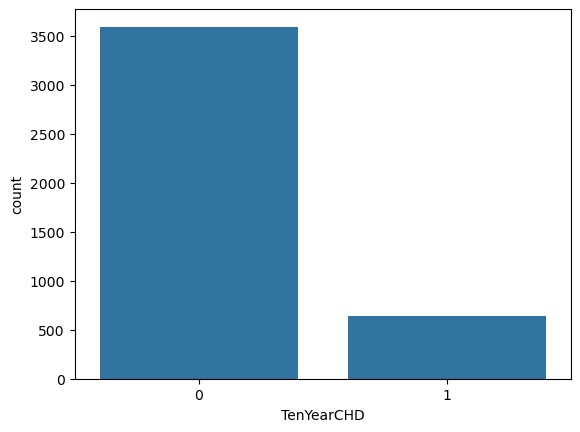

In [ ]:
sns.countplot(x="TenYearCHD",data=df)
plt.show()

Histograms

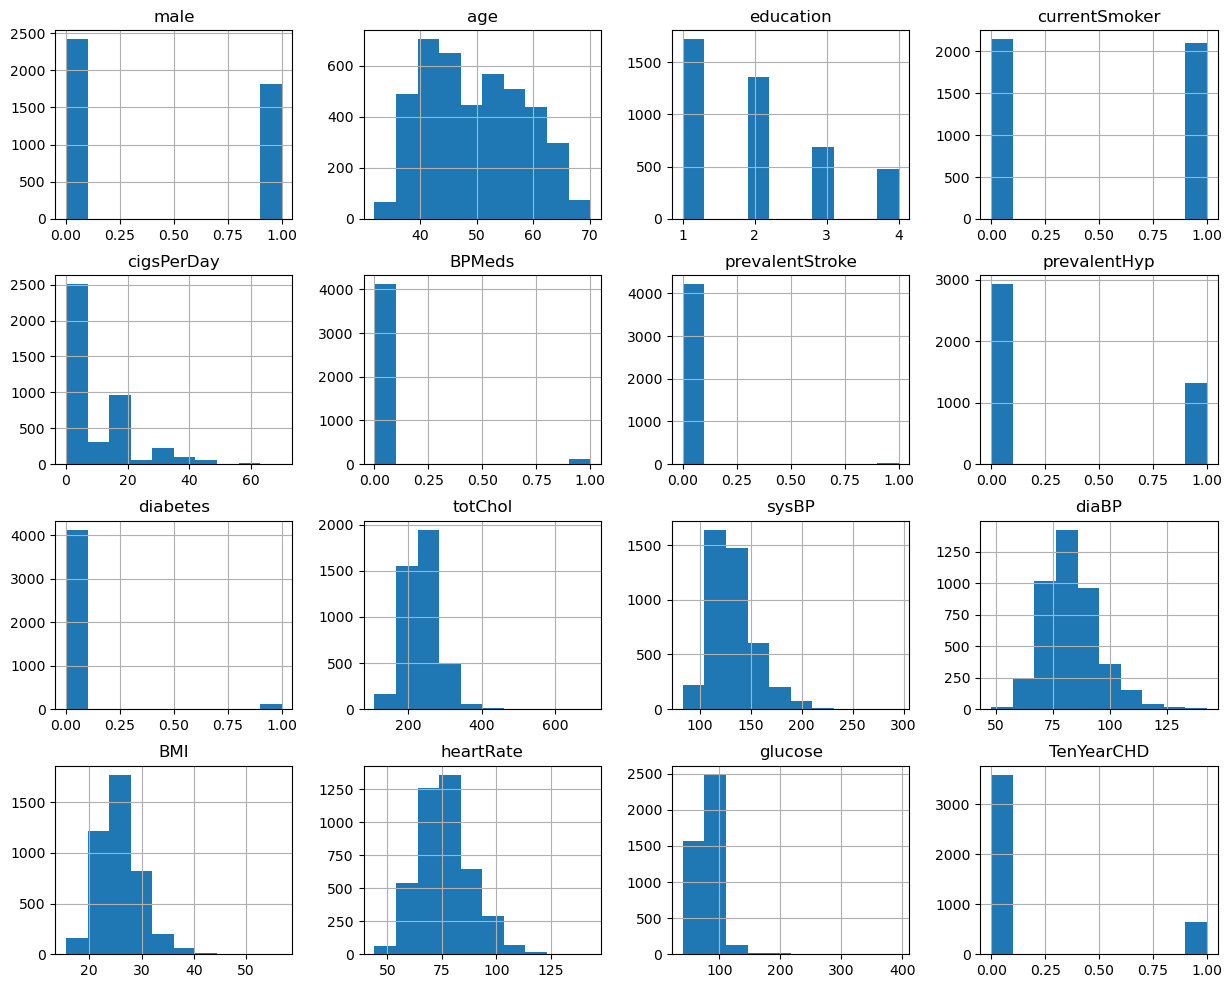

In [ ]:
df.hist(figsize=(15,12))
plt.show()

Correlation Heatmap

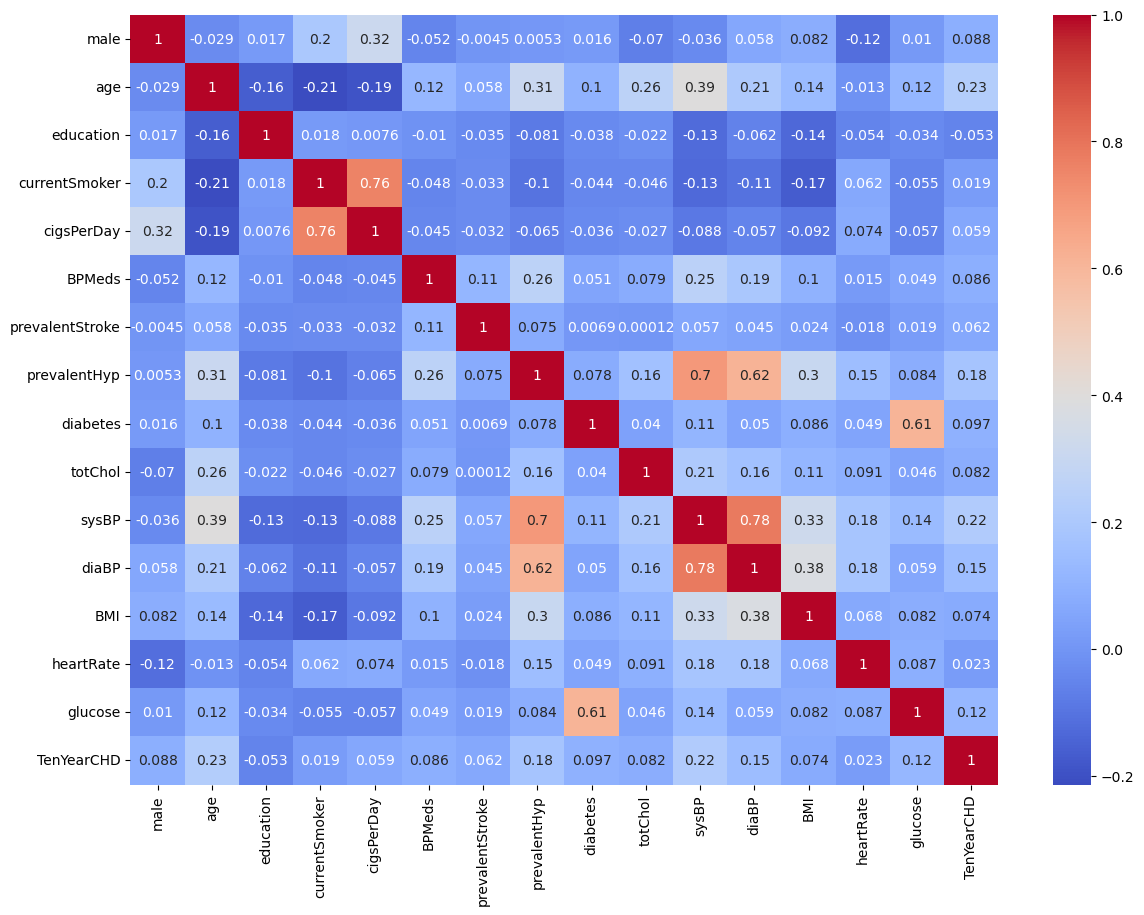

In [ ]:
plt.figure(figsize=(14,10))
sns.heatmap(df.corr(),annot=True,cmap="coolwarm")
plt.show()

Boxplots

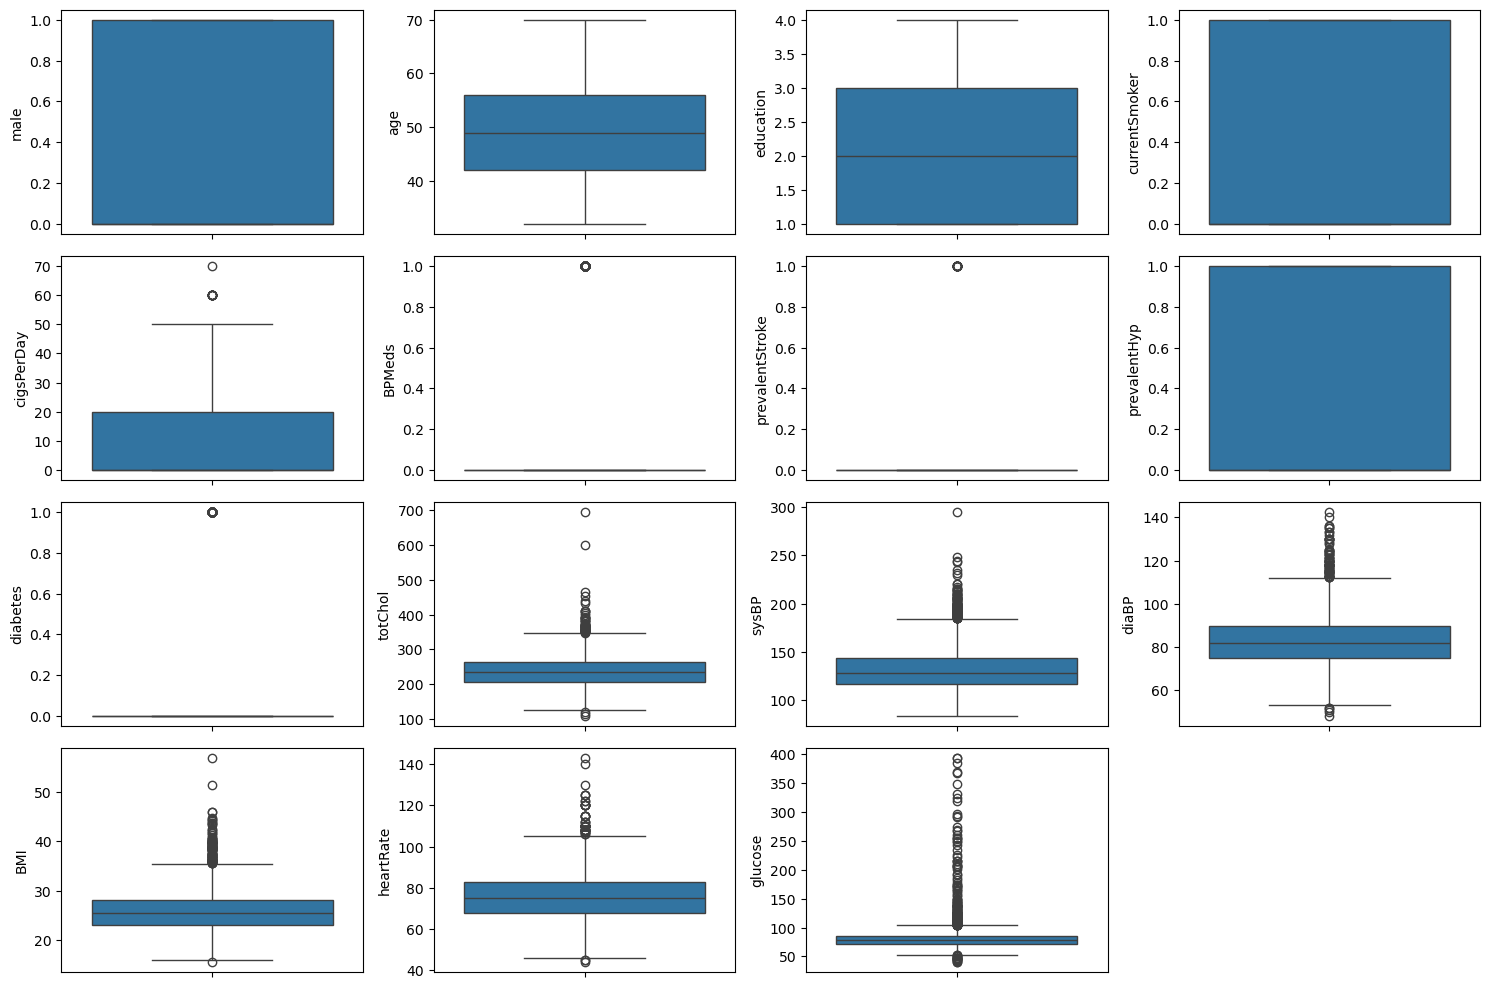

In [ ]:
plt.figure(figsize=(15,10))

for i,col in enumerate(df.columns[:-1]):
    plt.subplot(4,4,i+1)
    sns.boxplot(y=df[col])

plt.tight_layout()
plt.show()

Data Preprocessing

Separate Features and Target

In [ ]:
X=df.drop("TenYearCHD",axis=1)

y=df["TenYearCHD"]

Import Train Test Split

In [ ]:
from sklearn.model_selection import train_test_split

Split Dataset

In [ ]:
X_train,X_test,y_train,y_test=train_test_split(
X,
y,
test_size=0.2,
random_state=42,
stratify=y
)

Import StandardScaler

In [ ]:
from sklearn.preprocessing import StandardScaler

Feature Scaling

In [ ]:
scaler=StandardScaler()

X_train=scaler.fit_transform(X_train)

X_test=scaler.transform(X_test)

Machine Learning Models

Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression

lr=LogisticRegression(max_iter=1000)

lr.fit(X_train,y_train)

lr_pred=lr.predict(X_test)

Decision Tree

In [ ]:
from sklearn.tree import DecisionTreeClassifier

dt=DecisionTreeClassifier(random_state=42)

dt.fit(X_train,y_train)

dt_pred=dt.predict(X_test)

Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf=RandomForestClassifier(random_state=42)

rf.fit(X_train,y_train)

rf_pred=rf.predict(X_test)

KNN

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

knn=KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train,y_train)

knn_pred=knn.predict(X_test)

SVM

In [ ]:
from sklearn.svm import SVC

svm=SVC(kernel="rbf",probability=True)

svm.fit(X_train,y_train)

svm_pred=svm.predict(X_test)

Naive Bayes

In [ ]:
from sklearn.naive_bayes import GaussianNB

nb=GaussianNB()

nb.fit(X_train,y_train)

nb_pred=nb.predict(X_test)

Model Evaluation

In [ ]:
from sklearn.metrics import accuracy_score

from sklearn.metrics import precision_score

from sklearn.metrics import recall_score

from sklearn.metrics import f1_score

from sklearn.metrics import confusion_matrix

from sklearn.metrics import classification_report

from sklearn.metrics import roc_curve

from sklearn.metrics import roc_auc_score

Evaluation Function

In [ ]:
def evaluate(y_test,pred):

    print("Accuracy :",accuracy_score(y_test,pred))

    print("Precision:",precision_score(y_test,pred))

    print("Recall :",recall_score(y_test,pred))

    print("F1 Score :",f1_score(y_test,pred))

    print(classification_report(y_test,pred))

    cm=confusion_matrix(y_test,pred)

    sns.heatmap(cm,annot=True,fmt='d',cmap="Blues")

    plt.xlabel("Predicted")

    plt.ylabel("Actual")

    plt.show()

Evaluate Every Model

Logistic Regression
Accuracy : 0.847877358490566
Precision: 0.5
Recall : 0.06976744186046512
F1 Score : 0.12244897959183673
              precision    recall  f1-score   support

           0       0.86      0.99      0.92       719
           1       0.50      0.07      0.12       129

    accuracy                           0.85       848
   macro avg       0.68      0.53      0.52       848
weighted avg       0.80      0.85      0.80       848



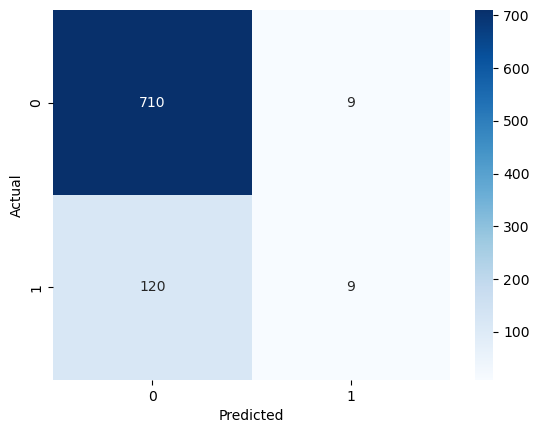

In [ ]:
print("Logistic Regression")
evaluate(y_test,lr_pred)

Decision Tree
Accuracy : 0.7417452830188679
Precision: 0.1917808219178082
Recall : 0.21705426356589147
F1 Score : 0.20363636363636364
              precision    recall  f1-score   support

           0       0.86      0.84      0.85       719
           1       0.19      0.22      0.20       129

    accuracy                           0.74       848
   macro avg       0.52      0.53      0.52       848
weighted avg       0.76      0.74      0.75       848



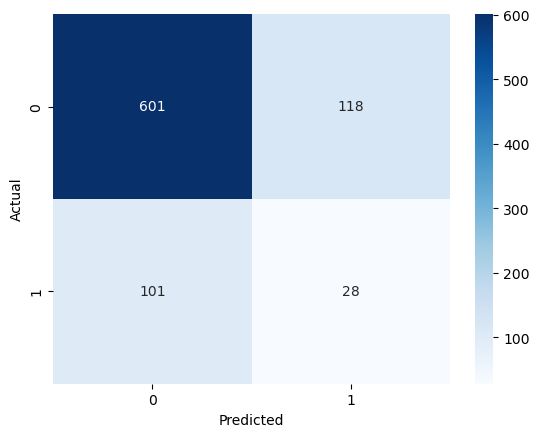

In [ ]:
print("Decision Tree")
evaluate(y_test,dt_pred)

Random Forest
Accuracy : 0.8419811320754716
Precision: 0.3076923076923077
Recall : 0.031007751937984496
F1 Score : 0.056338028169014086
              precision    recall  f1-score   support

           0       0.85      0.99      0.91       719
           1       0.31      0.03      0.06       129

    accuracy                           0.84       848
   macro avg       0.58      0.51      0.49       848
weighted avg       0.77      0.84      0.78       848



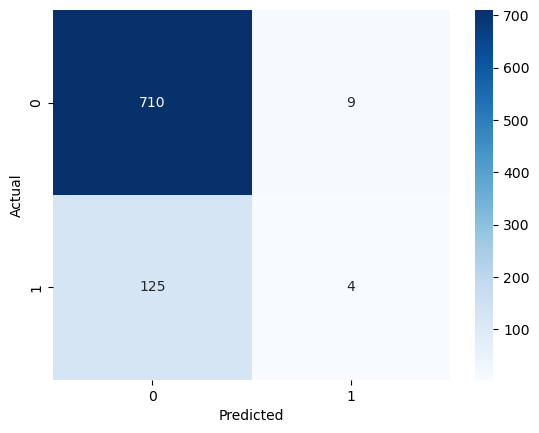

In [ ]:
print("Random Forest")
evaluate(y_test,rf_pred)

KNN
Accuracy : 0.8313679245283019
Precision: 0.28125
Recall : 0.06976744186046512
F1 Score : 0.11180124223602485
              precision    recall  f1-score   support

           0       0.85      0.97      0.91       719
           1       0.28      0.07      0.11       129

    accuracy                           0.83       848
   macro avg       0.57      0.52      0.51       848
weighted avg       0.77      0.83      0.79       848



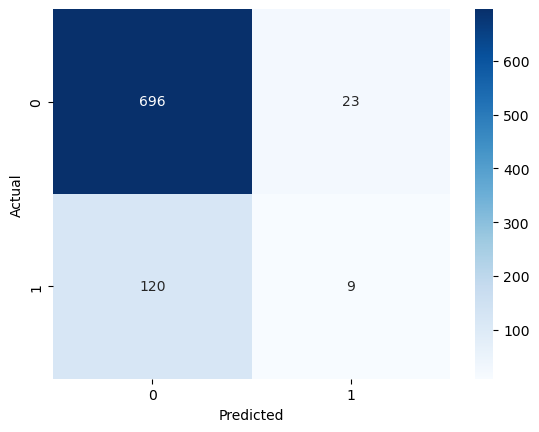

In [ ]:
print("KNN")
evaluate(y_test,knn_pred)

SVM
Accuracy : 0.8502358490566038
Precision: 0.6666666666666666
Recall : 0.031007751937984496
F1 Score : 0.05925925925925926
              precision    recall  f1-score   support

           0       0.85      1.00      0.92       719
           1       0.67      0.03      0.06       129

    accuracy                           0.85       848
   macro avg       0.76      0.51      0.49       848
weighted avg       0.82      0.85      0.79       848



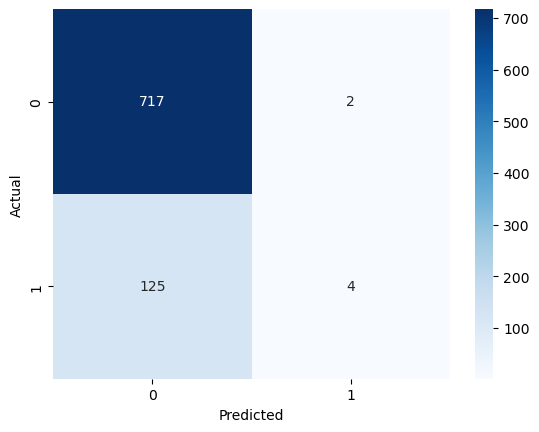

In [ ]:
print("SVM")
evaluate(y_test,svm_pred)

Naive Bayes
Accuracy : 0.8066037735849056
Precision: 0.2535211267605634
Recall : 0.13953488372093023
F1 Score : 0.18
              precision    recall  f1-score   support

           0       0.86      0.93      0.89       719
           1       0.25      0.14      0.18       129

    accuracy                           0.81       848
   macro avg       0.56      0.53      0.54       848
weighted avg       0.77      0.81      0.78       848



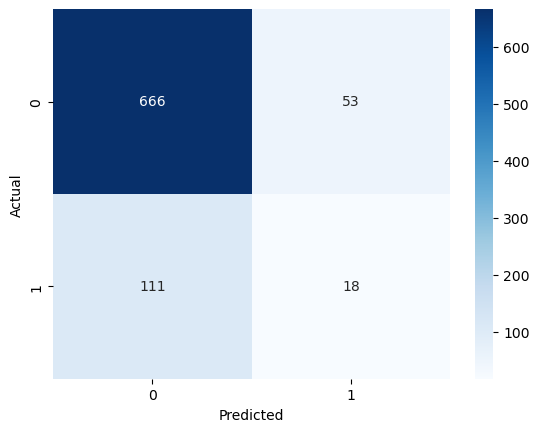

In [ ]:
print("Naive Bayes")
evaluate(y_test,nb_pred)

cross validation

In [ ]:
from sklearn.model_selection import cross_val_score

In [ ]:
models=[lr,dt,rf,knn,svm,nb]

for model in models:

    score=cross_val_score(model,X,y,cv=5)

    print(model.__class__.__name__)

    print(score.mean())

c:\Users\bkdbh\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\bkdbh\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please als

LogisticRegression
0.8532331090864538
DecisionTreeClassifier
0.7666375219977278
RandomForestClassifier
0.8482783297320176
KNeighborsClassifier
0.8357699761644873
SVC
0.847805796262057
GaussianNB
0.8230302287763696


Model Comparison
 Compare Models

In [ ]:
results=[]

models={
"Logistic Regression":lr,
"Decision Tree":dt,
"Random Forest":rf,
"KNN":knn,
"SVM":svm,
"Naive Bayes":nb
}

for name,model in models.items():

    pred=model.predict(X_test)

    results.append([

        name,

        accuracy_score(y_test,pred),

        precision_score(y_test,pred),

        recall_score(y_test,pred),

        f1_score(y_test,pred)

    ])

comparison=pd.DataFrame(results,

columns=["Model","Accuracy","Precision","Recall","F1 Score"])

comparison.sort_values("Accuracy",ascending=False)

,Model,Accuracy,Precision,Recall,F1 Score
4,SVM,0.850236,0.666667,0.031008,0.059259
0,Logistic Regression,0.847877,0.500000,0.069767,0.122449
2,Random Forest,0.841981,0.307692,0.031008,0.056338
3,KNN,0.831368,0.281250,0.069767,0.111801
5,Naive Bayes,0.806604,0.253521,0.139535,0.180000
1,Decision Tree,0.741745,0.191781,0.217054,0.203636
